# Week 4: Hypotheses from Raw Listings Data

This notebook is your workspace for this week’s assignment.

Follow the tasks in the README:
- Pull a dataset from the [form](https://docs.google.com/forms/d/e/1FAIpQLSdQQMShcp2OaFkdOclqkJN5hmWjWsowEte62WrglmW1S61Vkw/viewform?usp=header)
- Explore and clean
- Formulate and test a hypothesis about samples
- Reflect

--- 

## Setup

Import the packages you’ll need. Stick to the core libraries unless you have a strong reason to add more.



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


## Load Your Dataset

You should have received one or more CSV files by email after filling out the Google Form.

Replace `'your_file.csv'` below with the path to your dataset. If you have more than one data set, it may make sense to keep the separate as we did on the Mystery Box exercise.


In [3]:
file_path = "data.csv"
listings = pd.read_csv(file_path)

listings.tail()


,state,location,time_posted,name,make,model,year,odometer,price,title,...,drive,cylinders,fuel,type,transmission,condition,title_text,latitude,longitude,url
306159,California,palmsprings,2024-08-11 10:47:20,Jeep Wrangler,jeep,wrangler,2009.0,148000.0,9500.0,clean,...,4wd,6 cylinders,gas,other,automatic,fair,2009 Jeep Wrangler,33.809800,-116.466500,https://palmsprings.craigslist.org/cto/d/cathe...
306160,California,santamaria,2024-08-11 10:04:44,jeep wrangler unlimited,jeep,wrangler,2006.0,182885.0,12000.0,clean,...,4wd,6 cylinders,gas,offroad,automatic,good,2006,34.936662,-120.234777,https://santamaria.craigslist.org/cto/d/santa-...
306161,California,sfbay,2024-08-11 09:41:43,jeep wrangler jk unlimited,jeep,wrangler,2017.0,58777.0,30000.0,clean,...,4wd,6 cylinders,gas,NaN,manual,good,2017 Jeep Rubicon JKU,37.135300,-121.650100,https://sfbay.craigslist.org/sby/cto/d/morgan-...
306162,California,sfbay,2024-08-11 09:27:46,jeep Wrangler,jeep,wrangler,2001.0,174000.0,9800.0,clean,...,NaN,NaN,gas,NaN,manual,NaN,2001 Jeep Wrangler 4X4 5-Speed,37.637400,-122.067000,https://sfbay.craigslist.org/eby/cto/d/hayward...
306163,California,sfbay,2024-08-11 08:53:20,Jeep Wrangler,jeep,wrangler,1989.0,203787.0,12500.0,clean,...,4wd,6 cylinders,gas,offroad,manual,good,1989 Jeep Wrangler YJ with Flat Tow Kit,37.241700,-121.955400,https://sfbay.craigslist.org/sby/cto/d/los-gat...


In [4]:
listings.shape

(306164, 21)

In [5]:
listings.columns

Index(['state', 'location', 'time_posted', 'name', 'make', 'model', 'year',
       'odometer', 'price', 'title', 'paint', 'drive', 'cylinders', 'fuel',
       'type', 'transmission', 'condition', 'title_text', 'latitude',
       'longitude', 'url'],
      dtype='object')

In [10]:
object_cols = listings.select_dtypes(include=['object']).columns
print(object_cols)

Index(['state', 'location', 'name', 'make', 'model', 'title', 'paint', 'drive',
       'cylinders', 'fuel', 'type', 'transmission', 'condition', 'title_text',
       'url'],
      dtype='object')


In [11]:
num_cols = listings.select_dtypes(include=['float']).columns
print(num_cols)

Index(['year', 'odometer', 'price', 'latitude', 'longitude'], dtype='object')


In [12]:
listings["time_posted"] = pd.to_datetime(listings["time_posted"], errors="coerce")

In [13]:
for col in object_cols:
    listings[col] = listings[col].str.lower().str.strip()

In [14]:
listings.head(5)

,state,location,time_posted,name,make,model,year,odometer,price,title,...,drive,cylinders,fuel,type,transmission,condition,title_text,latitude,longitude,url
0,california,slo,2025-01-19 14:58:47,audi a3,audi,3,2010.0,160000.0,4200.0,clean,...,NaN,4 cylinders,gas,sedan,automatic,good,2010 audi a3,35.2635,-120.6509,https://slo.craigslist.org/cto/d/san-luis-obis...
1,florida,miami,2025-01-19 11:21:43,audi q3 prestige,audi,3,2017.0,112445.0,10900.0,clean,...,fwd,4 cylinders,gas,suv,automatic,excellent,audi q3 2017 prestige s line,26.1502,-80.2745,https://miami.craigslist.org/brw/cto/d/fort-la...
2,florida,miami,2025-01-19 11:21:43,audi q3 prestige,audi,3,2017.0,112445.0,10900.0,clean,...,fwd,4 cylinders,gas,suv,automatic,excellent,audi q3 2017 prestige s line,26.1502,-80.2745,https://miami.craigslist.org/brw/cto/d/fort-la...
3,florida,miami,2025-01-19 11:21:43,audi q3 prestige,audi,3,2017.0,112445.0,10900.0,clean,...,fwd,4 cylinders,gas,suv,automatic,excellent,audi q3 2017 prestige s line,26.1502,-80.2745,https://miami.craigslist.org/brw/cto/d/fort-la...
4,florida,miami,2025-01-19 11:21:43,audi q3 prestige,audi,3,2017.0,112445.0,10900.0,clean,...,fwd,4 cylinders,gas,suv,automatic,excellent,audi q3 2017 prestige s line,26.1502,-80.2745,https://miami.craigslist.org/brw/cto/d/fort-la...


## Initial Exploration

Look at the structure and summary of the dataset.


In [15]:
listings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 306164 entries, 0 to 306163
Data columns (total 21 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   state         306164 non-null  object        
 1   location      306164 non-null  object        
 2   time_posted   306164 non-null  datetime64[ns]
 3   name          305890 non-null  object        
 4   make          306164 non-null  object        
 5   model         306164 non-null  object        
 6   year          305892 non-null  float64       
 7   odometer      305803 non-null  float64       
 8   price         298934 non-null  float64       
 9   title         305892 non-null  object        
 10  paint         215525 non-null  object        
 11  drive         199830 non-null  object        
 12  cylinders     241764 non-null  object        
 13  fuel          305890 non-null  object        
 14  type          255847 non-null  object        
 15  transmission  305

In [16]:
missing = listings.isnull().sum()
print(missing)

state                0
location             0
time_posted          0
name               274
make                 0
model                0
year               272
odometer           361
price             7230
title              272
paint            90639
drive           106334
cylinders        64400
fuel               274
type             50317
transmission       272
condition        53934
title_text           0
latitude          7202
longitude         7202
url                  0
dtype: int64


In [17]:
listings.describe()

,time_posted,year,odometer,price,latitude,longitude
count,306164,305892.000000,3.058030e+05,298934.000000,298962.000000,298962.000000
mean,2024-09-11 05:32:01.901500672,2008.722422,1.450418e+05,9580.172289,33.837530,-103.095609
min,2023-06-26 15:37:55,1900.000000,0.000000e+00,0.000000,-79.698978,-159.344800
25%,2024-04-08 10:32:04.500000,2005.000000,9.850000e+04,4300.000000,29.751700,-119.165100
50%,2024-09-10 13:11:28,2009.000000,1.393970e+05,6995.000000,33.914300,-117.011500
75%,2025-03-19 12:14:44.500000,2014.000000,1.790000e+05,11995.000000,37.750900,-81.714600
max,2025-10-04 09:03:08,2026.000000,1.000000e+07,200000.000000,66.565600,166.643400
std,NaN,7.160779,1.753024e+05,9136.205229,5.347012,18.590443


#### Q: What quirks or issues do you notice in the data?

- Are there missing values?
- Any odd or outlier entries?
- Any columns that need cleaning?

Write your answers in a Markdown or in comments.  
The dataset has several issues. Important columns like price, odometer, and year have missing values. Categorical columns such as paint, drive, cylinders, type, and condition also have many missing entries. There are outliers: year ranges from 1900 to 2026, odometer goes from 0 to 10,000,000, and price includes 0 and extremely high values. To clean the data, year, odometer, and price should be limited to realistic ranges, while categorical columns can be imputed, labeled as "unknown", or dropped if necessary

## Cleaning

Use the techniques we’ve practiced (dropping observations, handling missing values, truncating ranges, etc.).


In [18]:
# Here are some examples, but I wouldn't use these...
# listings = listings.dropna(subset=["price"])
# listings = listings[listings["odometer"] < 300000]

clean_listings = listings.copy()

In [19]:
clean_listings = clean_listings.dropna(subset=["price"]) #around 7K missing values so decided to drop the missing vals

In [19]:
clean_listings["year"] = clean_listings["year"].fillna(clean_listings["year"].median())
clean_listings["odometer"] = clean_listings["odometer"].fillna(clean_listings["odometer"].median())

In [20]:
clean_listings = clean_listings[clean_listings["year"].between(2000, 2025)]
clean_listings = clean_listings[clean_listings["odometer"].between(1000, 300000)]
clean_listings = clean_listings[clean_listings["price"].between(500, 15000)]
clean_listings = clean_listings[~clean_listings["make"].isin(["audi", "saab"])]
clean_listings.reset_index(drop=True, inplace=True)

In [21]:
print(f"Total State: {clean_listings['state'].nunique()}")
print(clean_listings['state'].value_counts())
print()
print(f"Total Make: {clean_listings['make'].nunique()}")
print(clean_listings['make'].value_counts())
print()
print(f"Total Model: {clean_listings['model'].nunique()}")
print(clean_listings['model'].value_counts())

Total State: 6
state
california    111046
florida        49822
texas          28801
new york       15495
illinois        7348
minnesota       5603
Name: count, dtype: int64

Total Make: 6
make
toyota    85877
honda     46709
ford      41726
bmw       19966
lexus     12487
jeep      11350
Name: count, dtype: int64

Total Model: 7
model
camry       50515
accord      46709
f150        41726
prius       35362
3           19966
es          12487
wrangler    11350
Name: count, dtype: int64


#### Q: What cleaning steps did you apply and why?

<!-- Your answer down here. But remove these comments characters. -->
I cleaned the dataset by filling missing values in year and odometer with the median and dropping rows with missing price because it had around 7K missing values while year and odometer had only a few hundred. 
I filtered year to be between 2000 and 2025 because the minimum was 1900, the maximum 2026, and the mean and standard deviation suggested this range was reasonable, and similarly filtered odometer to be between 1,000 and 300,000 and price to be between $500 and $15,000, using the 75th percentile to set generous upper bounds since the maximum values were clear outliers. 
I also removed Audi and Saab because I didn’t request their data and Audi’s model label overlapped with BMW, and finally reset the index to ensure a clean, sequential ordering.

--- 

## Formulating a Hypothesis

Your hypothesis should:
- Involve **samples**, not whole populations.
- Include a **statistic** and a **reference distribution** (data generating process).

Example: *A sample of 50 Camrys from 2015–2020 in California will have higher mileage than a sample of 50 Camrys from Texas.*

#### Q: State your hypothesis here

<!-- Your answer down here. But remove these comments characters. -->
In random samples of 50 listings each from the High Efficiency Sedans and Trucks/Utility Vehicles categories across the six states (California, Florida, Texas, New York, Illinois, Minnesota), the average odometer reading for High Efficiency Sedans will be higher than for Trucks/Utility Vehicles.

In [22]:
# Your code here
def categorize_vehicle(model):
    if model in ["prius", "camry", "accord"]:
        return "High Efficiency Sedans"
    elif model in ["3", "es"]:
        return "Luxury Sedans"
    elif model in ["f150", "wrangler"]:
        return "Trucks / Utility Vehicles"
    else:
        return "other"

clean_listings["vehicle_category"] = clean_listings["model"].apply(categorize_vehicle)

print(clean_listings["vehicle_category"].value_counts())

vehicle_category
High Efficiency Sedans       132586
Trucks / Utility Vehicles     53076
Luxury Sedans                 32453
Name: count, dtype: int64


In [23]:
filtered_listings = clean_listings[
    clean_listings["vehicle_category"].isin(["High Efficiency Sedans", "Trucks / Utility Vehicles"])
].copy()
print(filtered_listings["vehicle_category"].value_counts())

vehicle_category
High Efficiency Sedans       132586
Trucks / Utility Vehicles     53076
Name: count, dtype: int64


## Testing Your Hypothesis 

Use the tools you know so far:
- Sampling (`.sample()`)
- Grouping (`.groupby()`)
- Simple comparisons and plots


In [24]:
# Your code here
np.random.seed(2025)  # For reproducibility
my_states = ["california", "florida", "texas", "new york", "illinois", "minnesota"]
my_model = ["camry", "accord", "prius", "f150", "wrangler"]

high_eff = clean_listings[clean_listings["vehicle_category"] == "High Efficiency Sedans"]["odometer"].values
trucks = clean_listings[clean_listings["vehicle_category"] == "Trucks / Utility Vehicles"]["odometer"].values


obs_diff = high_eff.mean() - trucks.mean()
print("Observed difference (High Efficiency Sedans - Trucks):", obs_diff)


Observed difference (High Efficiency Sedans - Trucks): -6830.276865681342


In [25]:
diffs = []
n = 1000
sample_size = 50

for _ in range(n):
    sample_high_eff = np.random.choice(high_eff, size=sample_size, replace=True)
    sample_truck = np.random.choice(trucks, size=sample_size, replace=True)
    diff = sample_high_eff.mean() - sample_truck.mean()
    diffs.append(diff)

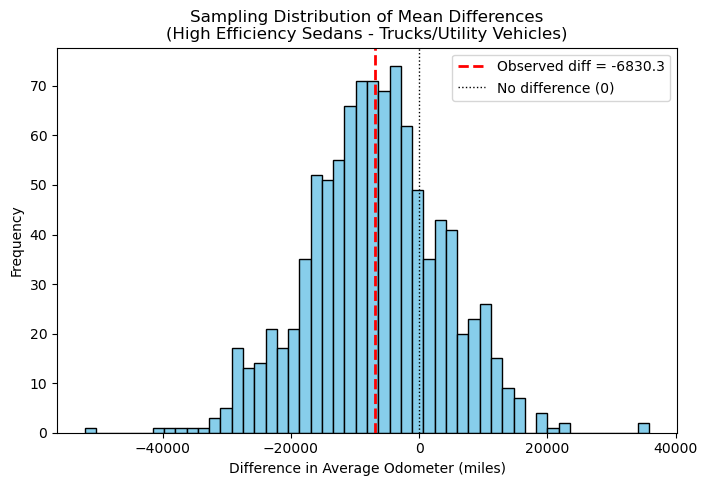

In [26]:
diffs = np.array(diffs)
plt.figure(figsize=(8,5))
plt.hist(diffs, bins=50, color='skyblue', edgecolor='black')
plt.axvline(obs_diff, color='red', linestyle='--', linewidth=2, label=f"Observed diff = {obs_diff:.1f}")
plt.axvline(0, color='black', linestyle=':', linewidth=1, label='No difference (0)')
plt.title("Sampling Distribution of Mean Differences\n(High Efficiency Sedans - Trucks/Utility Vehicles)")
plt.xlabel("Difference in Average Odometer (miles)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [27]:
p_value = np.mean(np.abs(diffs) >= abs(obs_diff))
print("Fraction of replicates more extreme than observed difference:", p_value)

Fraction of replicates more extreme than observed difference: 0.602


#### Q: What do your samples suggest about your hypothesis?

The hypothesis expected High Efficiency Sedans to have a higher average odometer reading than Trucks/Utility Vehicles. However, the observed difference in our samples is -6,823 miles, suggesting High Efficiency Sedans actually have slightly lower average mileage.

## Reflection

- What did you conclude?
- Re-run your analysis without cleaning (or with minimal cleaning). Did your conclusions change?
- If you had drawn a different sample, how might your conclusions have changed?  
- How does thinking in terms of **samples** (rather than entire populations) change the way you interpret your results?


#### Write your reflection below here



Conclusion:
My hypothesis predicted that High Efficiency Sedans would have higher mileage than Trucks. The data showed the opposite: Trucks had, on average, about 6,823 more miles.

Re-running without cleaning:
After cleaning and preparing the data, there were no missing or strange values, so re-running the analysis gives the same result.

Effect of drawing different samples:
We took random samples of 50 vehicles from each group and calculated the difference in average mileage many times. The observed difference (-6,823) is close to zero compared to the resampled differences, and the fraction of replicates more extreme than this value (0.596) shows it could easily happen by chance. This means there is no significant difference between High Efficiency Sedans and Trucks.

Thinking in terms of samples:
Looking at samples reminds us that our results are estimates, not exact truths, and observed differences might be due to random chance.